In [5]:
from dotenv import load_dotenv, find_dotenv

assert load_dotenv(find_dotenv(usecwd=False)), "The .env file was not loaded."

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from drn import DRN, DDR, GLM, drn_cutpoints, train
import seaborn as sns

torch.set_num_threads(1)

In [6]:
DATA_DIR = Path("data/processed/synth")
x_train = pd.read_csv(DATA_DIR / "x_train.csv")
x_val = pd.read_csv(DATA_DIR / "x_val.csv")
x_test = pd.read_csv(DATA_DIR / "x_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")
y_val = pd.read_csv(DATA_DIR / "y_val.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv")

X_train = torch.Tensor(x_train.values)
X_val = torch.Tensor(x_val.values)
X_test = torch.Tensor(x_test.values)
Y_train = torch.Tensor(y_train.values).flatten()
Y_val = torch.Tensor(y_val.values).flatten()
Y_test = torch.Tensor(y_test.values).flatten()

In [7]:
MODEL_DIR = Path("models/implicit_reg")
glm = torch.load(MODEL_DIR / "glm.pkl", weights_only=False)
ddr = torch.load(MODEL_DIR / "ddr.pkl", weights_only=False)
drn_small_kl = torch.load(MODEL_DIR / "drn_small_kl.pkl", weights_only=False)
drn_medium_kl = torch.load(MODEL_DIR / "drn_medium_kl.pkl", weights_only=False)
drn_large_kl = torch.load(MODEL_DIR / "drn_large_kl.pkl", weights_only=False)

In [8]:
PLOT_DIR = Path("plots/implicit_reg")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Training

In [10]:

c_0 = min(Y_train.min().item() * 1.05, 0.0)
c_K = Y_train.max().item() * 1.05
cutpoints = drn_cutpoints(
    c_0,
    c_K,
    proportion=0.025,
    y=Y_train.detach().numpy(),
    min_obs=5,
)

glm = GLM('gamma').fit(X_train, Y_train,)

drn_small_kl = DRN(
            baseline=glm,
            cutpoints=cutpoints,
            loss_metric="jbce",
            kl_alpha=0.0,
            hidden_size=256,
            num_hidden_layers=4,
            dropout_rate=0.0,
            learning_rate=1e-4,
            baseline_start=False,
        ).fit(
            X_train, Y_train,
            X_train, Y_train,
            epochs=100, patience=100, batch_size=128,
        )
        
drn_medium_kl = DRN(
            baseline=glm,
            cutpoints=cutpoints,
            loss_metric="jbce",
            kl_alpha=0.01,
            hidden_size=256,
            num_hidden_layers=4,
            dropout_rate=0.0,
            learning_rate=1e-4,
            baseline_start=False,
        ).fit(
            X_train, Y_train,
            X_train, Y_train,
            epochs=100, patience=100, batch_size=128,
        )
        
drn_large_kl = DRN(
            baseline=glm,
            cutpoints=cutpoints,
            loss_metric="jbce",
            kl_alpha=0.05,
            hidden_size=256,
            num_hidden_layers=4,
            dropout_rate=0.0,
            learning_rate=1e-4,
            baseline_start=False,
        ).fit(
            X_train, Y_train,
            X_train, Y_train,
            epochs=100, patience=100, batch_size=128,
        )
        
ddr =  DDR(
            cutpoints=cutpoints,
            loss_metric="jbce",
            hidden_size=256,
            num_hidden_layers=4,
            dropout_rate=0.0,
            learning_rate=1e-4,
        ).fit(
            X_train, Y_train,
            X_train, Y_train,
            epochs=100, patience=100, batch_size=128,
        )


torch.save(glm, MODEL_DIR/"glm.pkl")
torch.save(drn_small_kl,  MODEL_DIR/"drn_small_kl.pkl")
torch.save(drn_medium_kl,  MODEL_DIR/"drn_medium_kl.pkl")
torch.save(drn_large_kl,  MODEL_DIR/"drn_large_kl.pkl")
torch.save(ddr, MODEL_DIR/"ddr.pkl")

/Users/ericdong/opt/anaconda3/envs/project1/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
/Users/ericdong/opt/anaconda3/envs/project1/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'baseline' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['baseline'])`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/ericdong/opt/anaconda3/envs/project1/lib/python3.10/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:493: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accura

Epoch 99: 100%|██████████| 94/94 [00:02<00:00, 34.54it/s, train_loss=0.223, val_loss=0.234]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 94/94 [00:02<00:00, 34.37it/s, train_loss=0.223, val_loss=0.234]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | glm           | GLM        | 4      | train
1 | hidden_layers | Sequential | 197 K  | train
2 | fc_output     | Linear     | 22.1 K | train
  | other params  | n/a        | 87     | n/a  
-----------------------------------------------------
219 K     Trainable params
91        Non-trainable params
219 K     Total params
0.878     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode


...

Epoch 99: 100%|██████████| 94/94 [00:02<00:00, 37.71it/s, train_loss=0.249, val_loss=0.236]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type       | Params | Mode 
-----------------------------------------------------
0 | hidden_layers | Sequential | 197 K  | train
1 | pi            | Linear     | 22.1 K | train
  | other params  | n/a        | 87     | n/a  
-----------------------------------------------------
219 K     Trainable params
87        Non-trainable params
219 K     Total params
0.878     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode



Epoch 99: 100%|██████████| 94/94 [00:02<00:00, 41.55it/s, train_loss=0.248, val_loss=0.235]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 94/94 [00:02<00:00, 41.50it/s, train_loss=0.248, val_loss=0.235]


# Visualisation

In [11]:
# DATA_DIR = Path("data/processed/synth")
# x_test = pd.read_csv(DATA_DIR / "x_test.csv")
# X_test = torch.Tensor(x_test.values)
# X_test = X_test[:10000]
X_test = X_train

In [12]:
GRID_SIZE = 3000
grid = torch.linspace(0.0, np.max(y_train) * 1.1, GRID_SIZE).unsqueeze(-1)[1:]
print('zero kl')
logprob_drn_small_kl = (
    drn_small_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('medium kl')
logprob_drn_medium_kl = drn_medium_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('large kl')
logprob_drn_large_kl = (
    drn_large_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('ddr')
logprob_ddr = ddr.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('baseline')
logprob_baseline = glm.predict(X_test).log_prob(grid).detach().cpu().numpy().T

zero kl
medium kl
large kl
ddr
baseline


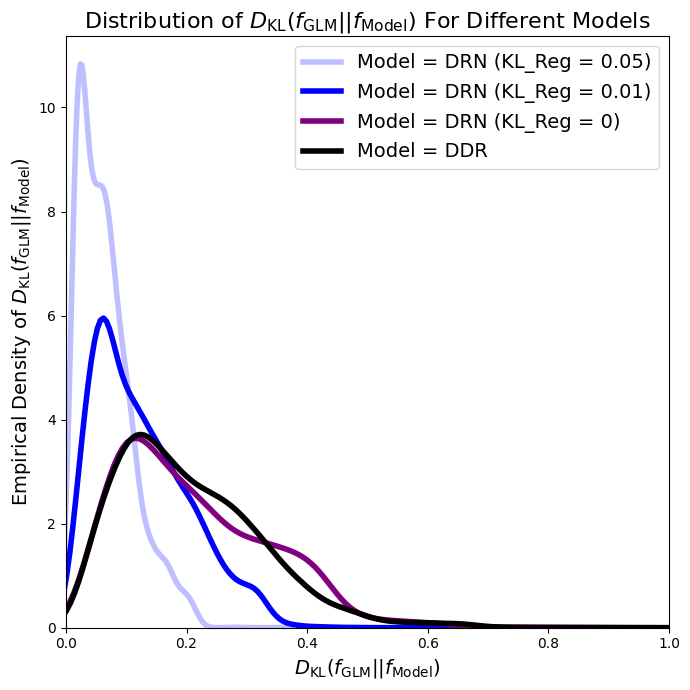

In [14]:
# Convert log-probs to probabilities
prob_drn_medium_kl = np.exp(logprob_drn_medium_kl)
prob_drn_small_kl = np.exp(logprob_drn_small_kl)
prob_drn_large_kl = np.exp(logprob_drn_large_kl)
prob_ddr = np.exp(logprob_ddr)
prob_baseline = np.exp(logprob_baseline)

# Add small epsilon to avoid division by zero or log(0)
epsilon = 1e-12
prob_drn_medium_kl = np.clip(prob_drn_medium_kl, epsilon, None)
prob_drn_small_kl = np.clip(prob_drn_small_kl, epsilon, None)
prob_drn_large_kl = np.clip(prob_drn_large_kl, epsilon, None)
prob_ddr = np.clip(prob_ddr, epsilon, None)

# Compute Δy (uniform grid spacing)
delta_y = (grid[1] - grid[0]).item()

# Compute KL divergence for each test point
kl_divs_drn_medium_kl = (
    - np.sum(prob_baseline * (np.log(prob_drn_medium_kl) - np.log(prob_baseline)), axis=1) * delta_y
)
kl_divs_drn_small_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_small_kl) - np.log(prob_baseline)), axis=1
    )
    * delta_y
)
kl_divs_drn_large_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_large_kl) - np.log(prob_baseline)), axis=1
    )
    * delta_y
)
kl_divs_ddr = (
    - np.sum(prob_baseline * (np.log(prob_ddr) - np.log(prob_baseline)), axis=1) * delta_y
)
# Define consistent bins for overlapping histogram
bin_width = 0.01 / 2
max_val = max(np.max(kl_divs_drn_medium_kl), np.max(kl_divs_ddr))
bins = np.arange(0, max_val + bin_width, bin_width)

# Create the plot
plt.figure(figsize=(7, 7))

# Plot KDEs for each KL divergence group
sns.kdeplot(
    kl_divs_drn_large_kl,
    label="Model = DRN (KL_Reg = 0.05)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=0.25,
)
sns.kdeplot(
    kl_divs_drn_medium_kl,
    label="Model = DRN (KL_Reg = 0.01)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=1.0,
)
sns.kdeplot(
    kl_divs_drn_small_kl,
    label="Model = DRN (KL_Reg = 0)",
    bw_adjust=1.5,
    linewidth=4,
    color="purple",
    alpha=1.0,
)
sns.kdeplot(kl_divs_ddr, label="Model = DDR", bw_adjust=1.5, linewidth=4, color="black")

# Axes and formatting
plt.title(
    "Distribution of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$ For Different Models",
    fontsize=16,
)
plt.xlabel("$D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$", fontsize=14)
plt.ylabel(
    "Empirical Density of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$",
    fontsize=14,
)
plt.xlim([0, 1.0])
# plt.ylim([0, 5000])
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / "_Synthetic_Distr_KL_Training_Data.png");

In [11]:
DATA_DIR = Path("data/processed/synth")
x_test = pd.read_csv(DATA_DIR / "x_test.csv")
X_test = torch.Tensor(x_test.values)
X_test[:, 0] = X_test[:, 0]+5
X_test[:, 1] = X_test[:, 1]+5
print(X_test[:10])
GRID_SIZE = 3000
grid = torch.linspace(0.0, np.max(y_train) * 1.1, GRID_SIZE).unsqueeze(-1)[1:]
print('zero kl')
logprob_drn_small_kl = (
    drn_small_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('medium kl')
logprob_drn_medium_kl = drn_medium_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('large kl')
logprob_drn_large_kl = (
    drn_large_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('ddr')
logprob_ddr = ddr.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('baseline')
logprob_baseline = glm.predict(X_test).log_prob(grid).detach().cpu().numpy().T

tensor([[5.4776, 5.5059],
        [5.4268, 5.6678],
        [5.6328, 5.1398],
        [2.0318, 4.8697],
        [5.8320, 3.8499],
        [3.1701, 4.4549],
        [4.3392, 4.9806],
        [4.6625, 4.4246],
        [4.7644, 5.0654],
        [4.7685, 4.8501]])
zero kl
medium kl
large kl
ddr
baseline


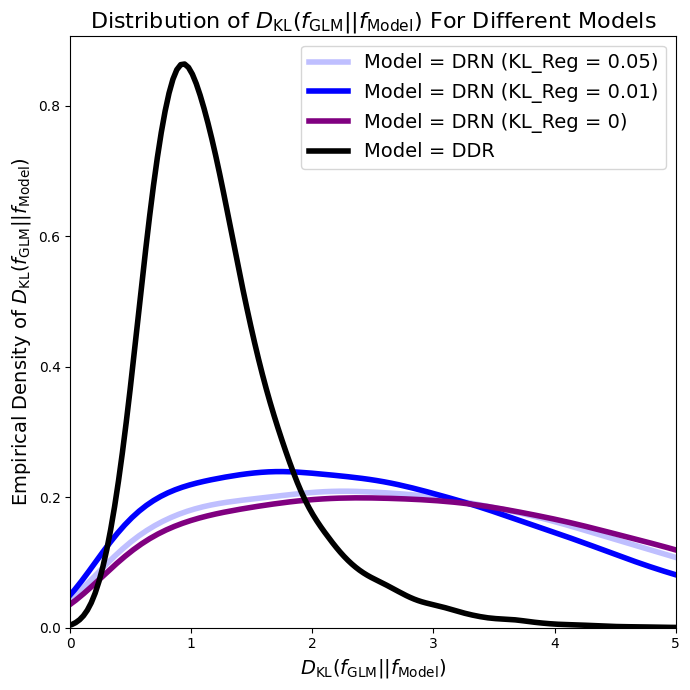

In [13]:
# Convert log-probs to probabilities
prob_drn_medium_kl = np.exp(logprob_drn_medium_kl)
prob_drn_small_kl = np.exp(logprob_drn_small_kl)
prob_drn_large_kl = np.exp(logprob_drn_large_kl)
prob_ddr = np.exp(logprob_ddr)
prob_baseline = np.exp(logprob_baseline)

# Add small epsilon to avoid division by zero or log(0)
epsilon = 1e-12
prob_drn_medium_kl = np.clip(prob_drn_medium_kl, epsilon, None)
prob_drn_small_kl = np.clip(prob_drn_small_kl, epsilon, None)
prob_drn_large_kl = np.clip(prob_drn_large_kl, epsilon, None)
prob_ddr = np.clip(prob_ddr, epsilon, None)

# Compute Δy (uniform grid spacing)
delta_y = (grid[1] - grid[0]).item()

# Compute KL divergence for each test point
kl_divs_drn_medium_kl = (
    - np.sum(prob_baseline * (np.log(prob_drn_medium_kl + 1e-12) - np.log(prob_baseline + 1e-12)), axis=1) * delta_y
)
kl_divs_drn_small_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_small_kl+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1
    )
    * delta_y
)
kl_divs_drn_large_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_large_kl+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1
    )
    * delta_y
)
kl_divs_ddr = (
    - np.sum(prob_baseline * (np.log(prob_ddr+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1) * delta_y
)
# Define consistent bins for overlapping histogram
bin_width = 0.01 / 2
max_val = max(np.max(kl_divs_drn_medium_kl), np.max(kl_divs_ddr))
bins = np.arange(0, max_val + bin_width, bin_width)

# Create the plot
plt.figure(figsize=(7, 7))

# Plot KDEs for each KL divergence group
sns.kdeplot(
    kl_divs_drn_large_kl,
    label="Model = DRN (KL_Reg = 0.05)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=0.25,
)
sns.kdeplot(
    kl_divs_drn_medium_kl,
    label="Model = DRN (KL_Reg = 0.01)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=1.0,
)
sns.kdeplot(
    kl_divs_drn_small_kl,
    label="Model = DRN (KL_Reg = 0)",
    bw_adjust=1.5,
    linewidth=4,
    color="purple",
    alpha=1.0,
)
sns.kdeplot(kl_divs_ddr, label="Model = DDR", bw_adjust=1.5, linewidth=4, color="black")

# Axes and formatting
plt.title(
    "Distribution of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$ For Different Models",
    fontsize=16,
)
plt.xlabel("$D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$", fontsize=14)
plt.ylabel(
    "Empirical Density of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$",
    fontsize=14,
)
plt.xlim([0, 5.0])
# plt.ylim([0, 5000])
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / "_Synthetic_Distr_KL_Val_Data.png");

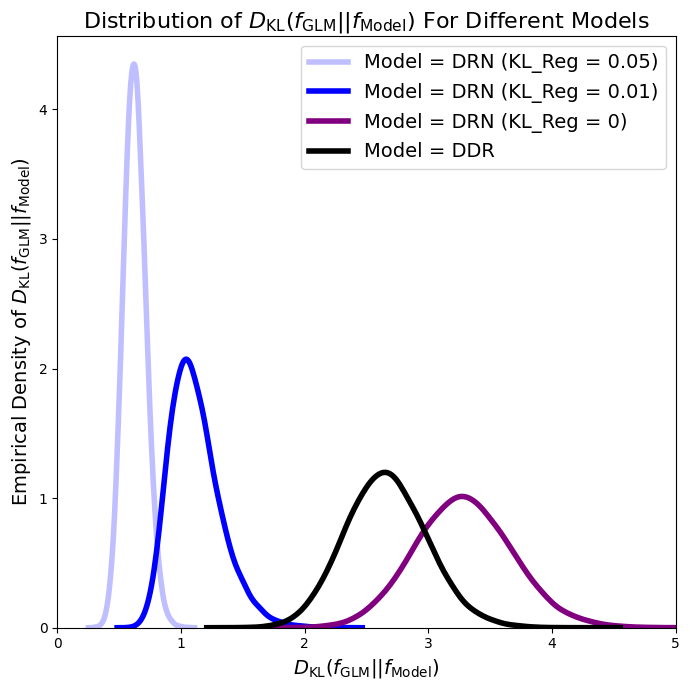

In [ ]:


GRID_SIZE = 3000
grid = torch.linspace(0.0, np.max(y_train) * 1.1, GRID_SIZE).unsqueeze(-1)[1:]
print('zero kl')
logprob_drn_small_kl = (
    drn_small_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('medium kl')
logprob_drn_medium_kl = drn_medium_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('large kl')
logprob_drn_large_kl = (
    drn_large_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('ddr')
logprob_ddr = ddr.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('baseline')
logprob_baseline = glm.predict(X_test).log_prob(grid).detach().cpu().numpy().T


# Convert log-probs to probabilities
prob_drn_medium_kl = np.exp(logprob_drn_medium_kl)
prob_drn_small_kl = np.exp(logprob_drn_small_kl)
prob_drn_large_kl = np.exp(logprob_drn_large_kl)
prob_ddr = np.exp(logprob_ddr)
prob_baseline = np.exp(logprob_baseline)

# Add small epsilon to avoid division by zero or log(0)
epsilon = 1e-12
prob_drn_medium_kl = np.clip(prob_drn_medium_kl, epsilon, None)
prob_drn_small_kl = np.clip(prob_drn_small_kl, epsilon, None)
prob_drn_large_kl = np.clip(prob_drn_large_kl, epsilon, None)
prob_ddr = np.clip(prob_ddr, epsilon, None)

# Compute Δy (uniform grid spacing)
delta_y = (grid[1] - grid[0]).item()

# Compute KL divergence for each test point
kl_divs_drn_medium_kl = (
    - np.sum(prob_baseline * (np.log(prob_drn_medium_kl + 1e-12) - np.log(prob_baseline + 1e-12)), axis=1) * delta_y
)
kl_divs_drn_small_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_small_kl+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1
    )
    * delta_y
)
kl_divs_drn_large_kl = (
    - np.sum(
        prob_baseline * (np.log(prob_drn_large_kl+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1
    )
    * delta_y
)
kl_divs_ddr = (
    - np.sum(prob_baseline * (np.log(prob_ddr+ 1e-12) - np.log(prob_baseline+ 1e-12)), axis=1) * delta_y
)
# Define consistent bins for overlapping histogram
bin_width = 0.01 / 2
max_val = max(np.max(kl_divs_drn_medium_kl), np.max(kl_divs_ddr))
bins = np.arange(0, max_val + bin_width, bin_width)

# Create the plot
plt.figure(figsize=(7, 7))

# Plot KDEs for each KL divergence group
sns.kdeplot(
    kl_divs_drn_large_kl,
    label="Model = DRN (KL_Reg = 0.05)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=0.25,
)
sns.kdeplot(
    kl_divs_drn_medium_kl,
    label="Model = DRN (KL_Reg = 0.01)",
    bw_adjust=1.5,
    linewidth=4,
    color="blue",
    alpha=1.0,
)
sns.kdeplot(
    kl_divs_drn_small_kl,
    label="Model = DRN (KL_Reg = 0)",
    bw_adjust=1.5,
    linewidth=4,
    color="purple",
    alpha=1.0,
)
sns.kdeplot(kl_divs_ddr, label="Model = DDR", bw_adjust=1.5, linewidth=4, color="black")

# Axes and formatting
plt.title(
    "Distribution of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$ For Different Models",
    fontsize=16,
)
plt.xlabel("$D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$", fontsize=14)
plt.ylabel(
    "Empirical Density of $D_{\\text{KL}}(f_{\\text{GLM}}||f_{\\text{Model}})$",
    fontsize=14,
)
plt.xlim([0, 5.0])
# plt.ylim([0, 5000])
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(PLOT_DIR / "_Synthetic_Distr_KL_Val_2_Data.png");

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Utilities
# -------------------------

def _to_numpy(X):
    """Return X as a NumPy array; works for NumPy arrays or PyTorch tensors."""
    try:
        # PyTorch tensor
        return X.detach().cpu().numpy().astype(float)
    except AttributeError:
        # NumPy or array-like
        return np.asarray(X, dtype=float)

def _to_pdf_from_logpdf(logpdf, grid, eps=1e-12):
    """
    Convert log-pdf evaluated on a grid to a normalized pdf over that grid.
    Expects shape (n_points, len(grid)). If input is (len(grid), n_points),
    it will be transposed automatically.
    """
    grid = np.asarray(grid).reshape(-1)  # ensure 1-D x

    arr = np.asarray(logpdf)
    if arr.ndim != 2:
        raise ValueError(f"logpdf must be 2-D, got shape {arr.shape}")

    # Ensure grid dimension is axis=1
    if arr.shape[1] != grid.size:
        if arr.shape[0] == grid.size:
            arr = arr.T
        else:
            raise ValueError(
                f"logpdf shape {arr.shape} not compatible with grid size {grid.size}. "
                "Expected (n_points, len(grid)) or (len(grid), n_points)."
            )

    pdf = np.exp(arr)
    pdf = np.clip(pdf, eps, None)

    # Normalize each row using trapz over possibly non-uniform grid
    integral = np.trapz(pdf, x=grid, axis=1)
    integral = np.clip(integral, eps, None)
    pdf /= integral[:, None]
    return pdf

def _kl_model_vs_glm(pdf_model, pdf_glm, grid, eps=1e-12):
    """
    Compute D_KL(model || glm) row-wise using trapz over `grid`.
    Natural log base (nats).
    """
    grid = np.asarray(grid).reshape(-1)  # ensure 1-D x

    if pdf_model.shape != pdf_glm.shape:
        raise ValueError(
            f"pdf_model and pdf_glm must have the same shape, got "
            f"{pdf_model.shape} vs {pdf_glm.shape}"
        )
    if pdf_model.ndim != 2:
        raise ValueError(f"PDFs must be 2-D, got {pdf_model.ndim} dims")

    # (pdf_* are already (n_points, len(grid)) from _to_pdf_from_logpdf)
    log_m = np.log(np.clip(pdf_model, 1e-12, None))
    log_g = np.log(np.clip(pdf_glm,   1e-12, None))
    integrand = pdf_glm * (log_g - log_m)
    return np.trapz(integrand, x=grid, axis=1)

def _js_model_vs_glm(pdf_model, pdf_glm, grid, eps=1e-12):
    """
    Compute JS divergence row-wise:
        JS(P||Q) = 0.5*KL(P||M) + 0.5*KL(Q||M),  with M = 0.5*(P+Q)
    Natural log base (nats).
    """
    M = 0.5 * (pdf_model + pdf_glm)
    M = np.clip(M, eps, None)
    # Normalize M to be safe (should already be normalized if P,Q are)
    grid = np.asarray(grid).reshape(-1)
    M /= np.clip(np.trapz(M, x=grid, axis=1)[:, None], eps, None)

    kl_pm = _kl_model_vs_glm(pdf_model, M, grid, eps=eps)
    kl_qm = _kl_model_vs_glm(pdf_glm,   M, grid, eps=eps)
    return 0.5 * (kl_pm + kl_qm)

def _scale_by_log_base(vals, base="e"):
    """
    Convert 'nats' to the requested base: 'e' (no-op), 2 (bits), or 10 (bans).
    """
    if base in (None, "e"):
        return vals
    if base == 2:
        return vals / np.log(2.0)
    if base == 10:
        return vals / np.log(10.0)
    raise ValueError("base must be 'e', 2, or 10")

# -------------------------
# Index picker (3x3 lattice)
# -------------------------

def _pick_3x3_indices(X_test, seed=123, p_lo=5, p_hi=95):
    """
    Pick 9 unique indices corresponding to a 3x3 lattice across the central range
    of X1 and X2 (between p_lo and p_hi percentiles to avoid extreme outliers).
    """
    rng = np.random.default_rng(seed)

    X = _to_numpy(X_test)
    x1 = X[:, 0]
    x2 = X[:, 1]
    x1_targets = np.linspace(np.percentile(x1, p_lo), np.percentile(x1, p_hi), 3)
    x2_targets = np.linspace(np.percentile(x2, p_lo), np.percentile(x2, p_hi), 3)

    chosen = []
    used = set()

    for a in x1_targets:
        for b in x2_targets:
            target = np.array([a, b])
            dists = np.linalg.norm(X - target, axis=1)
            order = np.argsort(dists)
            pick = None
            for idx in order:
                if idx not in used:
                    pick = idx
                    break
            if pick is None:
                remaining = np.setdiff1d(np.arange(X.shape[0]), np.array(list(used)))
                if remaining.size == 0:
                    break
                pick = rng.choice(remaining)
            used.add(pick)
            chosen.append(pick)

    chosen = chosen[:9]
    if len(chosen) < 9:
        remaining = np.setdiff1d(np.arange(X.shape[0]), np.array(chosen))
        pad = remaining[: (9 - len(chosen))]
        chosen = chosen + pad.tolist()
    return np.array(chosen)

# -------------------------
# Plotting with selectable divergence
# -------------------------

def plot_kl_grid_3x3(
    X_test,
    grid,
    logprob_drn_small_kl,
    logprob_drn_medium_kl,
    logprob_drn_large_kl,
    logprob_ddr,
    logprob_baseline,
    out_dir=None,
    figure_name="KL_grid_3x3.png",
    indices=None,
    annotate_values=True,
    divergence="kl",         # "kl" or "js"
    base="e",                # "e" (nats), 2 (bits), or 10 (bans)
    js_distance=False,       # if True and divergence="js", plot sqrt(JS)
):
    """
    Build a 3x3 grid of bar charts. Each subplot corresponds to one x=(x1, x2) test point
    and shows the selected divergence between f_Model and f_GLM for four models.

    Parameters
    ----------
    divergence : {"kl", "js"}
        - "kl": D_KL(f_Model || f_GLM)
        - "js": D_JS(f_Model || f_GLM) = 0.5*KL(Model||M) + 0.5*KL(GLM||M), M=(Model+GLM)/2
    base : {"e", 2, 10}
        Logarithm base for reporting magnitudes. For JS with base 2, range is [0, 1].
    js_distance : bool
        If True (and divergence="js"), plot sqrt(JS) — the Jensen–Shannon distance.
    """

    # ---- Convert log-probs to normalized PDFs over y ----
    pdf_glm   = _to_pdf_from_logpdf(logprob_baseline,     grid)
    pdf_drn0  = _to_pdf_from_logpdf(logprob_drn_small_kl, grid)   # KL_Reg = 0
    pdf_drn01 = _to_pdf_from_logpdf(logprob_drn_medium_kl,grid)   # KL_Reg = 0.01
    pdf_drn05 = _to_pdf_from_logpdf(logprob_drn_large_kl, grid)   # KL_Reg = 0.05
    pdf_ddr   = _to_pdf_from_logpdf(logprob_ddr,          grid)

    # ---- Choose divergence function ----
    if divergence == "kl":
        def _div(P):  # returns in nats
            return _kl_model_vs_glm(P, pdf_glm, grid)
        ylabel_core = r"$D_{\mathrm{KL}}(f_{\mathrm{Model}}\Vert f_{\mathrm{GLM}})$"
        title_core  = r"$D_{\mathrm{KL}}$"
    elif divergence == "js":
        def _div(P):  # returns JS in nats
            return _js_model_vs_glm(P, pdf_glm, grid)
        ylabel_core = r"$D_{\mathrm{JS}}(f_{\mathrm{Model}}\Vert f_{\mathrm{GLM}})$"
        title_core  = r"$D_{\mathrm{JS}}$"
    else:
        raise ValueError("divergence must be 'kl' or 'js'")

    # ---- Compute divergence per test point for each model ----
    vals_drn0  = _div(pdf_drn0)
    vals_drn01 = _div(pdf_drn01)
    vals_drn05 = _div(pdf_drn05)
    vals_ddr   = _div(pdf_ddr)

    # Rescale to requested base (e: nats; 2: bits; 10: bans)
    vals_drn0  = _scale_by_log_base(vals_drn0,  base)
    vals_drn01 = _scale_by_log_base(vals_drn01, base)
    vals_drn05 = _scale_by_log_base(vals_drn05, base)
    vals_ddr   = _scale_by_log_base(vals_ddr,   base)

    # Optional: convert JS -> distance
    if divergence == "js" and js_distance:
        vals_drn0  = np.sqrt(np.maximum(vals_drn0,  0.0))
        vals_drn01 = np.sqrt(np.maximum(vals_drn01, 0.0))
        vals_drn05 = np.sqrt(np.maximum(vals_drn05, 0.0))
        vals_ddr   = np.sqrt(np.maximum(vals_ddr,   0.0))
        ylabel_core = r"$\sqrt{D_{\mathrm{JS}}}(f_{\mathrm{Model}}\Vert f_{\mathrm{GLM}})$"
        title_core  = r"$\sqrt{D_{\mathrm{JS}}}$"

    # ---- Choose 9 test indices to display ----
    if indices is None:
        indices = _pick_3x3_indices(X_test)
    else:
        indices = np.asarray(indices)
        assert indices.size == 9, "If you pass indices, provide exactly 9 of them."

    # ---- Precompute global y-limit for consistent scaling ----
    # Order: DDR, DRN0, DRN01, DRN05
    all_vals = np.vstack([
        vals_ddr[indices], vals_drn0[indices], vals_drn01[indices], vals_drn05[indices]
    ])
    ymax = float(np.max(all_vals)) * 1.15 if np.isfinite(all_vals).all() else None

    # Labels and units
    labels = ["DDR", "DRN (KL=0)", "DRN (KL=0.01)", "DRN (KL=0.05)"]
    unit_suffix = "" if base in ("e", None) else (" [bits]" if base == 2 else " [bans]")

    # ---- Plot ----
    fig, axes = plt.subplots(3, 3, figsize=(12, 12), squeeze=True)
    axes = axes.ravel()

    for k, idx in enumerate(indices):
        ax = axes[k]
        values = [vals_ddr[idx], vals_drn0[idx], vals_drn01[idx], vals_drn05[idx]]
        x_pos = np.arange(len(labels))
        bars = ax.bar(x_pos, values)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(labels, rotation=25, ha="right")
        if ymax is not None:
            ax.set_ylim(0, ymax)
        xi = _to_numpy(X_test)
        ax.set_title(f"x=({xi[idx,0]:.2f}, {xi[idx,1]:.2f})", fontsize=10)
        if k % 3 == 0:
            ax.set_ylabel(ylabel_core + unit_suffix)
        if annotate_values:
            for rect, val in zip(bars, values):
                ax.text(
                    rect.get_x() + rect.get_width() / 2.0,
                    rect.get_height(),
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    fig.suptitle(
        rf"Per‑Point {title_core} across a 3×3 grid in $x\in\mathbb{{R}}^2$",
        fontsize=14
    )
    fig.tight_layout(rect=[0, 0.02, 1, 0.96])

    # Save if requested
    if out_dir is None:
        out_dir = Path(".")
    out_path = Path(out_dir) / figure_name
    fig.savefig(out_path, dpi=200)
    return indices, out_path, fig


In [34]:
GRID_SIZE = 3000
X_test = torch.Tensor([[0.0, 0.0],
                       [0.25, -0.25],
                        [-0.25, 0.25],
                        [0.5, 0.5],
                        [-0.5, -0.5],
                        [1.0, 1.0],
                        [-1.0, -1.0],
                        [1.0, -1.0],
                        [-1.0, 1.0],
                       ])
grid = torch.linspace(0.0, np.max(y_train) * 1.1, GRID_SIZE).unsqueeze(-1)[1:]
print('zero kl')
logprob_drn_small_kl = (
    drn_small_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('medium kl')
logprob_drn_medium_kl = drn_medium_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('large kl')
logprob_drn_large_kl = (
    drn_large_kl.predict(X_test).log_prob(grid).detach().cpu().numpy().T
)
print('ddr')
logprob_ddr = ddr.predict(X_test).log_prob(grid).detach().cpu().numpy().T
print('baseline')
logprob_baseline = glm.predict(X_test).log_prob(grid).detach().cpu().numpy().T

zero kl
medium kl
large kl
ddr
baseline


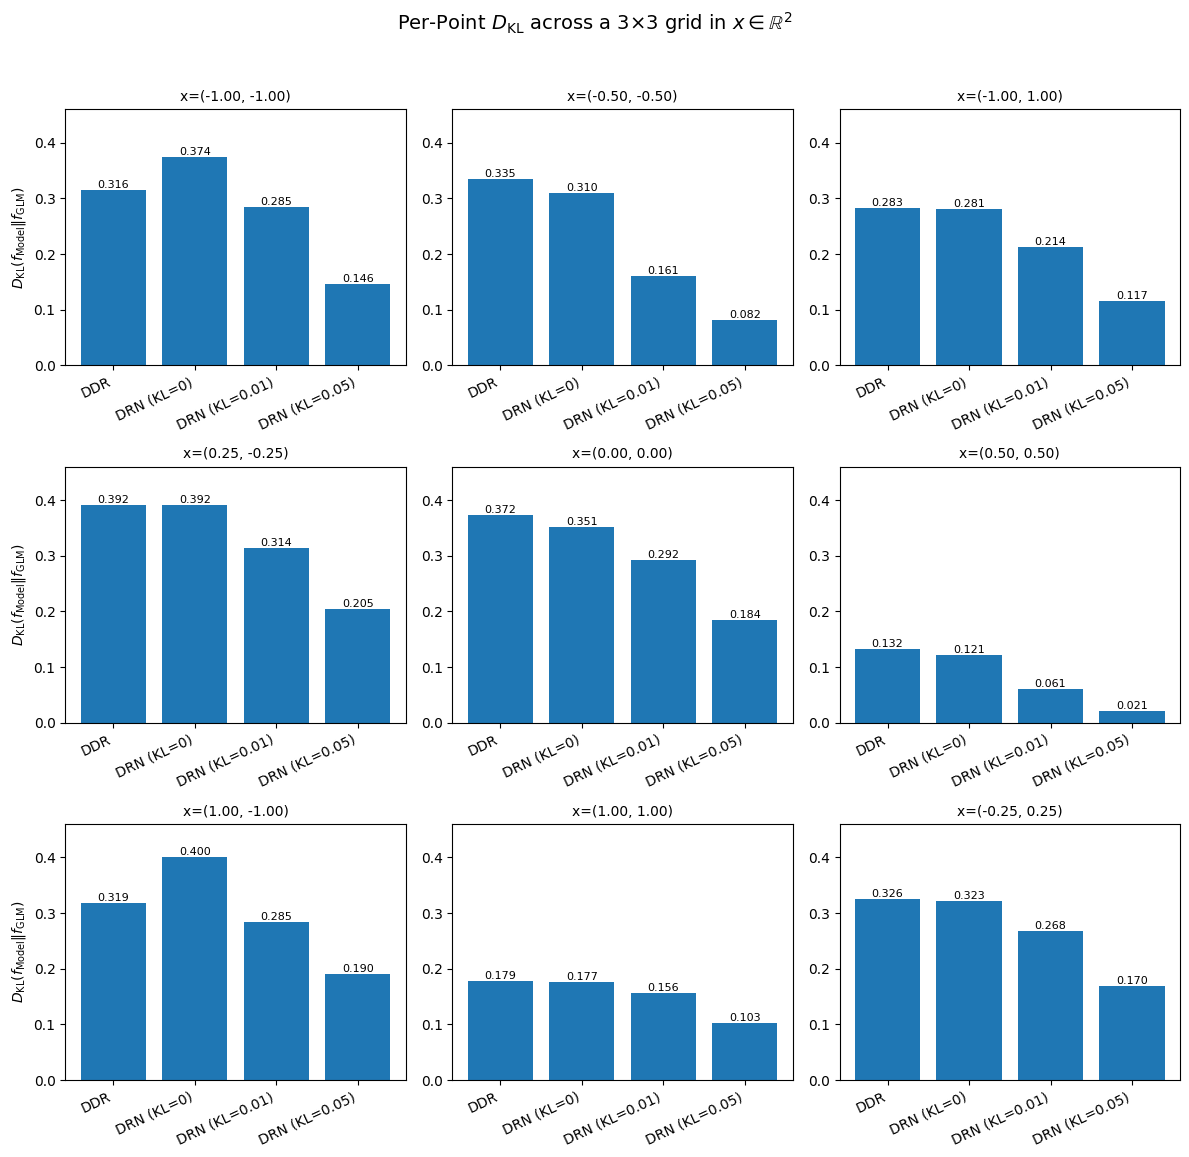

In [ ]:

# -------------------------
# Example usage
# -------------------------

indices, png_path, fig = plot_kl_grid_3x3(
    X_test,
    grid,
    logprob_drn_small_kl,
    logprob_drn_medium_kl,
    logprob_drn_large_kl,
    logprob_ddr,
    logprob_baseline,
    out_dir=PLOT_DIR,
    figure_name="_Synthetic_KL_Bars_3x3.png",
)
# print("Saved:", png_path)